In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
data = pd.read_csv("Salary_Data.csv")


In [10]:
data

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891
5,2.9,56642
6,3.0,60150
7,3.2,54445
8,3.2,64445
9,3.7,57189


In [11]:
X = data['YearsExperience'].values
y = data['Salary'].values

In [12]:
X

array([ 1.1,  1.3,  1.5,  2. ,  2.2,  2.9,  3. ,  3.2,  3.2,  3.7,  3.9,
        4. ,  4. ,  4.1,  4.5,  4.9,  5.1,  5.3,  5.9,  6. ,  6.8,  7.1,
        7.9,  8.2,  8.7,  9. ,  9.5,  9.6, 10.3, 10.5])

In [13]:
y

array([ 39343,  46205,  37731,  43525,  39891,  56642,  60150,  54445,
        64445,  57189,  63218,  55794,  56957,  57081,  61111,  67938,
        66029,  83088,  81363,  93940,  91738,  98273, 101302, 113812,
       109431, 105582, 116969, 112635, 122391, 121872])

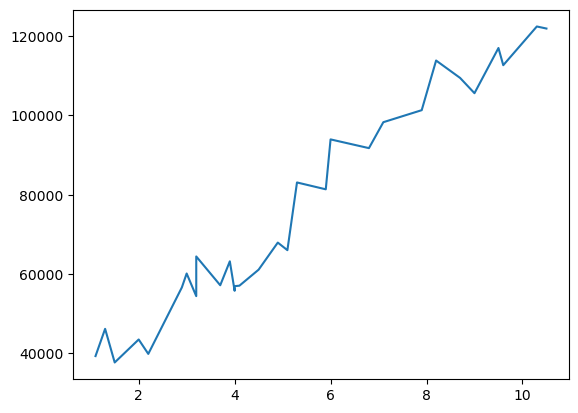

In [14]:
plt.plot(X,y)

In [15]:
X = np.array(X)
y = np.array(y)

In [16]:
def mean(X):
    return np.sum(X)/len(X)

In [17]:
def variance(X):
    mean_value = mean(X)
    return np.sum((X-mean_value)**2)/len(X)

In [18]:
def norm(X):
    mean_value = mean(X)
    variance_value = variance(X)
    return(X - mean_value)/np.sqrt(variance_value)

In [19]:
X_norm = norm(X)

In [20]:
X_norm

array([-1.51005294, -1.43837321, -1.36669348, -1.18749416, -1.11581443,
       -0.86493538, -0.82909552, -0.75741579, -0.75741579, -0.57821647,
       -0.50653674, -0.47069688, -0.47069688, -0.43485702, -0.29149756,
       -0.1481381 , -0.07645838, -0.00477865,  0.21026054,  0.2461004 ,
        0.53281931,  0.6403389 ,  0.92705781,  1.03457741,  1.21377673,
        1.32129632,  1.50049564,  1.5363355 ,  1.78721455,  1.85889428])

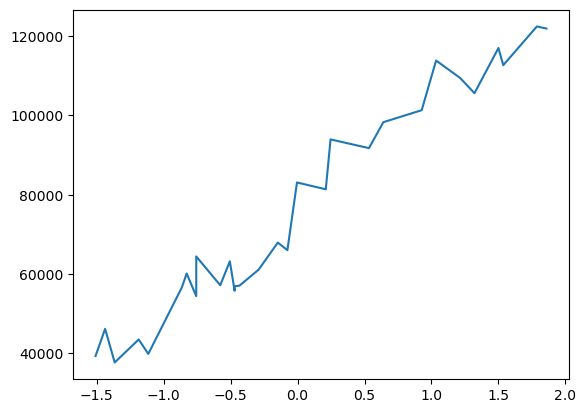

In [22]:
plt.plot(X_norm,y)


In [23]:
import random

In [33]:
class SimpleLR:
    def __init__(self, lr=0.1, max_iter=2000, threshold=1e-6):
        self.lr = lr
        self.max_iter = max_iter
        self.threshold = threshold
        self.weight = random.uniform(-1,1)
        self.bias = random.uniform(-1,1)
    def predict(self, X):
        return self.weight*X + self.bias
    def fit(self, X, Y):
        n = len(X)
        loss_history = []
        y_pred = self.predict(X)
        errors = Y-y_pred
        prev_loss = (1/(2*n)) * np.sum(errors**2)
        loss_history.append(prev_loss)
        for i in range(self.max_iter):
            w_grad = (1/n) * np.sum(errors*X)
            b_grad = (1/n) * np.sum(errors)
            self.weight += self.lr * w_grad
            self.bias += self.lr * b_grad
            y_pred = self.predict(X)
            errors = Y-y_pred
            curr_loss = (1/(2*n)) * np.sum(errors**2)
            if np.abs(curr_loss - prev_loss) < self.threshold:
                break
            prev_loss = curr_loss
            loss_history.append(curr_loss)
        return loss_history
    def plot(self, X, Y):
        y_pred = self.predict(X)
        plt.plot(X,Y)
        plt.plot(X,y_pred)


In [34]:
model = SimpleLR()

In [35]:
loss_history = model.fit(X_norm,y)


In [36]:
loss_history

[3251452847.860825,
 2636647547.180885,
 2138655253.6301334,
 1735281495.8540242,
 1408548752.0553768,
 1143895229.578472,
 929525876.3721789,
 755886700.2750816,
 615238967.6364326,
 501314304.199127,
 409035326.8149096,
 334289355.13369346,
 273745118.0719083,
 224704286.05186245,
 184981212.11562532,
 152805522.2272731,
 126743213.41770792,
 105632743.28196013,
 88533262.47200438,
 74682683.01594022,
 63463713.6565282,
 54376348.47540445,
 47015582.6786943,
 41053362.38335913,
 36223963.944137596,
 32312151.20836813,
 29143582.89239488,
 26577042.55645651,
 24498144.88434647,
 22814237.769937348,
 21450273.007265963,
 20345461.54950209,
 19450564.268713396,
 18725697.471274517,
 18138555.36534905,
 17662970.25954942,
 17277746.323851738,
 16965714.93593659,
 16712969.511725321,
 16508245.7181142,
 16342419.4452892,
 16208100.164300948,
 16099301.546700463,
 16011174.666444061,
 15939791.893436383,
 15881971.847300164,
 15835137.609929824,
 15797201.877659855,
 15766473.934521168,
 1

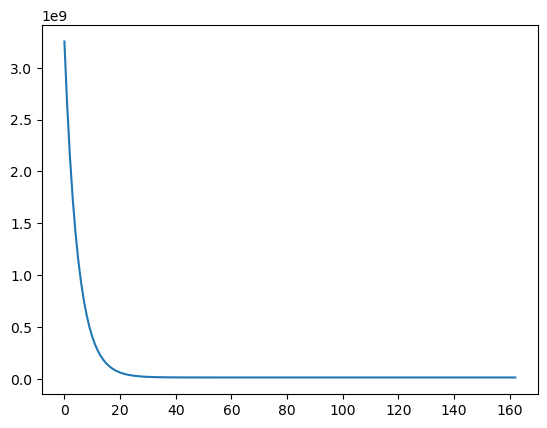

In [37]:
plt.plot(loss_history)


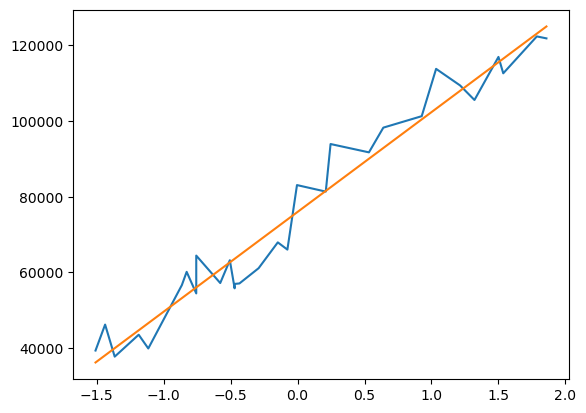

In [39]:
model.plot(X_norm,y)

